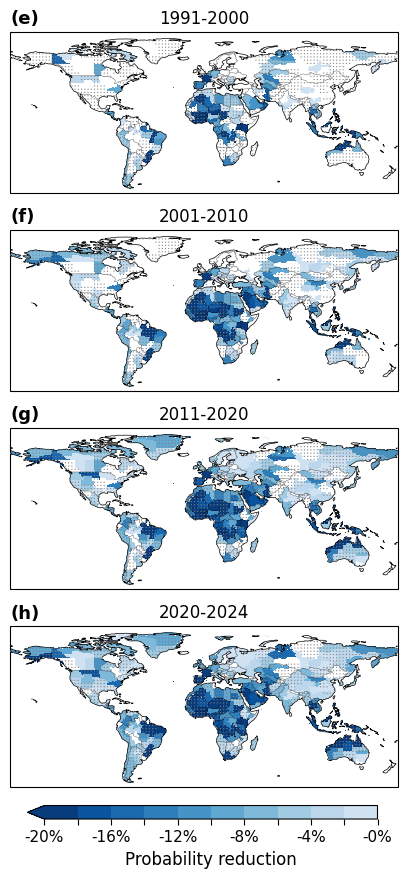

In [1]:
# ====================================================
# 只画 (b–e)，竖排 + 单一 colorbar（简化版）
# ====================================================

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.ticker import FuncFormatter
from matplotlib.colors import BoundaryNorm, ListedColormap
from matplotlib.gridspec import GridSpec
import matplotlib.cm as cm
from matplotlib.colors import to_hex


# ====================================================
# === 读取数据（核心变化）===
# ====================================================
ds = xr.open_dataset("record_breaking_probability_fixed_params.nc")

prob_map = ds["record_breaking_probability"].values  # (region, period)

# ====================================================
# mask & 经纬度（仍然需要）
# ====================================================
mask_ds = xr.open_dataset(
    "/home/users/kastanie/Global_regional_analysis/atmos-WRAF01-v4-1/region_mask_1deg.nc"
)

region_ids = mask_ds['region_id'].values
lat = mask_ds['latitude'].values
lon = mask_ds['longitude'].values
n_regions = len(ds.region_id)


# ====================================================
# fidelity（仍然需要）
# ====================================================
fidelity_ds = xr.open_dataset("grid_comparison_fidelity_trend_corrected.nc")
fidelity = fidelity_ds["fidelity_score"]
fidelity_mask = fidelity == 3


# ====================================================
# scatter 稀疏控制
# ====================================================
lat_stride = 3
lon_stride = 3

lon2d, lat2d = np.meshgrid(lon, lat)

stride_mask = np.zeros_like(region_ids, dtype=bool)
stride_mask[::lat_stride, ::lon_stride] = True


# ====================================================
# period labels（直接从 nc 读）
# ====================================================
period_labels = ds["period"].values


# ====================================================
# 绘图函数
# ====================================================
def plot_gev_probability_vertical(prob_map):

    fig = plt.figure(figsize=(5, 9))
    gs = GridSpec(4, 1, figure=fig)

    axs = [
        fig.add_subplot(gs[i, 0], projection=ccrs.PlateCarree())
        for i in range(4)
    ]

    
    labels = ["(e)", "(f)", "(g)", "(h)"]
    # =========================================
    # difference colormap
    # =========================================
    diff_bounds = np.arange(-0.20, 0.001, 0.02)

    blue_rgba = [cm.Blues(x) for x in np.linspace(
        0.95, 0.2, len(diff_bounds) - 1
    )]

    cmap_diff = ListedColormap([to_hex(c) for c in blue_rgba])
    cmap_diff.set_bad('white')

    norm_diff = BoundaryNorm(diff_bounds, cmap_diff.N)

    # =========================================
    # 画图
    # =========================================
    for i, ax in enumerate(axs):

        period_idx = i + 1  # 跳过 baseline

        title = period_labels[period_idx]

        diff = prob_map[:, period_idx] - prob_map[:, 0]

        map_data = np.full_like(region_ids, np.nan, dtype=float)

        for r in range(n_regions):
            map_data[region_ids == r] = diff[r]

        masked_map = np.ma.masked_where(map_data > -1e-6, map_data)

        ax.pcolormesh(
            lon, lat, masked_map,
            transform=ccrs.PlateCarree(),
            cmap=cmap_diff,
            norm=norm_diff
        )

        # fidelity dots
        valid_low = (
            (~fidelity_mask.values) &
            (~np.isnan(map_data)) &
            stride_mask
        )

        if np.any(valid_low):
            ax.scatter(
                lon2d[valid_low],
                lat2d[valid_low],
                s=0.8,
                color='grey',
                edgecolors='none',
                transform=ccrs.PlateCarree(),
                zorder=5
            )

        ax.set_extent([-180, 180, -60, 90])
        ax.coastlines(linewidth=0.5)
        ax.add_feature(cfeature.BORDERS, linewidth=0.2)

        ax.set_title(title, fontsize=12)

        ax.text(
            0.00, 1.05, labels[i],
            transform=ax.transAxes,
            fontsize=13,
            fontweight='bold',
            ha='left'
        )

    # =========================================
    # layout
    # =========================================
    fig.subplots_adjust(hspace=0.05, top=0.95, bottom=0.08)

    # =========================================
    # colorbar
    # =========================================
    cbar_ax = fig.add_axes([0.16, 0.06, 0.7, 0.015])

    formatter = FuncFormatter(lambda x, _: f"{x*100:.0f}%")

    cbar = fig.colorbar(
        plt.cm.ScalarMappable(norm=norm_diff, cmap=cmap_diff),
        cax=cbar_ax,
        orientation="horizontal",
        ticks=diff_bounds,
        extend="min"
    )

    cbar.set_label(
        "Probability reduction",
        fontsize=12
    )

    cbar.ax.set_xticklabels(
        [formatter(t) if i % 2 == 0 else "" for i, t in enumerate(diff_bounds)]
    )

    cbar.ax.tick_params(labelsize=11, length=4)

    # =========================================
    # save
    # =========================================
    plt.savefig(
        "Fig3_vertical_diff_only.pdf",
        dpi=200,
        bbox_inches='tight'
    )

    plt.show()


# ====================================================
# 执行
# ====================================================
plot_gev_probability_vertical(prob_map)

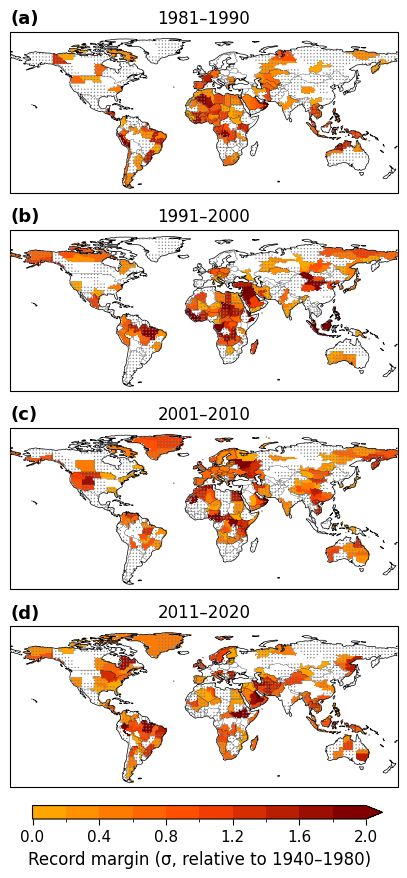

In [2]:
# ==========================================
# Record margin（前4个period + 竖排）
# ==========================================
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.colors import BoundaryNorm, ListedColormap, LinearSegmentedColormap
from matplotlib.gridspec import GridSpec

# ==========================================
# Load data
# ==========================================
ds = xr.open_dataset(
    "Berkeley_hottest_month_by_region_revised_by_ERA5.nc"
).sel(year=slice(1940, 2024))

region_mask_ds = xr.open_dataset(
    "/home/users/kastanie/Global_regional_analysis/atmos-WRAF01-v4-1/region_mask_1deg.nc"
)

fidelity_ds = xr.open_dataset(
    "grid_comparison_fidelity_trend_corrected.nc"
)

region_id_map = region_mask_ds["region_id"]
lat = region_mask_ds["latitude"].values
lon = region_mask_ds["longitude"].values
extent = [lon.min(), lon.max(), lat.min(), lat.max()]

# ==========================================
# Low fidelity mask（保留）
# ==========================================
fidelity_mask = (fidelity_ds["fidelity_score"] == 3).values
land_mask = ~np.isnan(region_id_map)
fill_grey_mask = land_mask & (~fidelity_mask)

lon2d, lat2d = np.meshgrid(lon, lat)

sparse_mask = np.zeros_like(fill_grey_mask)
sparse_mask[::3, ::3] = True
low_fidelity_sparse = fill_grey_mask & sparse_mask

# ==========================================
# Periods（只保留前4个）
# ==========================================
periods = {
    "1981–1990": (1981, 1990),
    "1991–2000": (1991, 2000),
    "2001–2010": (2001, 2010),
    "2011–2020": (2011, 2020),
}

period_names = list(periods.keys())

# ==========================================
# Record margin calculation
# ==========================================
t2m = ds["t2m_hottest"]

t2m_base = t2m.sel(year=slice(1940, 1980))
record_tracker = t2m_base.max(dim="year")
base_std = t2m_base.std(dim="year")

record_margin_maps = []

for pname in period_names:

    start, end = periods[pname]

    t2m_period = t2m.sel(year=slice(start, end))
    period_max = t2m_period.max(dim="year")

    margin = (period_max - record_tracker) / base_std
    margin = margin.where(period_max > record_tracker)

    record_tracker = xr.where(
        period_max > record_tracker,
        period_max,
        record_tracker
    )

    # 映射到格点
    margin_map = np.full(region_id_map.shape, np.nan)

    for rid in margin.region_id.values:
        margin_map[region_id_map.values == rid] = margin.sel(region_id=rid).values

    record_margin_maps.append(margin_map)

# ==========================================
# Colormap
# ==========================================
cmap_temp = LinearSegmentedColormap.from_list(
    "orange_red_custom",
    ["#FFA500", "#FF4500", "#800000"]
)

bounds = np.linspace(0, 2, 11)
cmap_common = ListedColormap([cmap_temp(i / 9) for i in range(10)])
norm_common = BoundaryNorm(bounds, cmap_common.N)

# ==========================================
# Plot（4×1 vertical）
# ==========================================
fig = plt.figure(figsize=(5, 9))
gs = GridSpec(4, 1, figure=fig)

axes = [
    fig.add_subplot(gs[i, 0], projection=ccrs.PlateCarree())
    for i in range(4)
]

labels = ['(a)', '(b)', '(c)', '(d)']

for i, ax in enumerate(axes):

    ax.set_extent([-180, 180, -60, 90])
    ax.coastlines(linewidth=0.5)
    ax.add_feature(cfeature.BORDERS, linewidth=0.2)

    ax.set_title(period_names[i], fontsize=12)

    ax.imshow(
        record_margin_maps[i],
        origin="lower",
        extent=extent,
        transform=ccrs.PlateCarree(),
        cmap=cmap_common,
        norm=norm_common
    )

    # fidelity dots
    ax.scatter(
        lon2d[low_fidelity_sparse],
        lat2d[low_fidelity_sparse],
        s=1,
        color="grey",
        edgecolors="none",
        transform=ccrs.PlateCarree(),
        zorder=5
    )

    ax.text(
        0.00, 1.05,
        labels[i],
        transform=ax.transAxes,
        fontsize=13,
        fontweight='bold'
    )

# ==========================================
# layout
# ==========================================
fig.subplots_adjust(hspace=0.05, top=0.95, bottom=0.08)

# ==========================================
# Colorbar（单一）
# ==========================================
cax = fig.add_axes([0.17, 0.06, 0.7, 0.015])

cb = fig.colorbar(
    plt.cm.ScalarMappable(cmap=cmap_common, norm=norm_common),
    cax=cax,
    orientation="horizontal",
    extend="max"
)

cb.ax.tick_params(labelsize=11, length=4)

cb.set_label(
    "Record margin (σ, relative to 1940–1980)",
    fontsize=12
)

# ==========================================
# Save
# ==========================================
plt.savefig(
    "FigS_record_margin_vertical.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

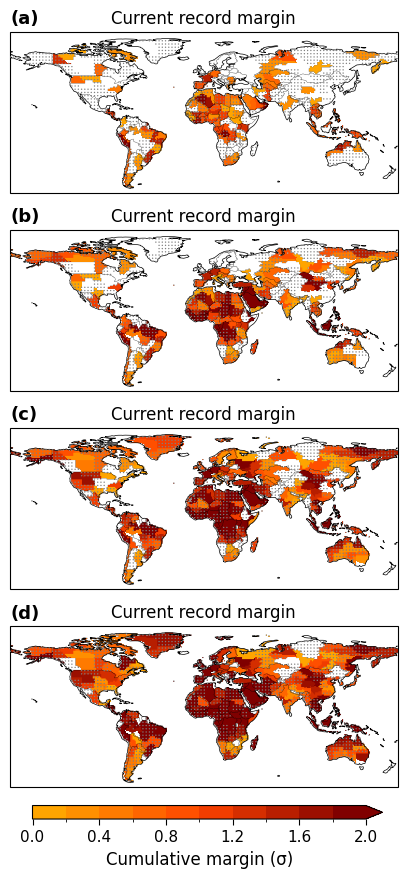

In [3]:
# ==========================================
# Record margin（累计版本 + 4×1）
# ==========================================
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.colors import BoundaryNorm, ListedColormap, LinearSegmentedColormap
from matplotlib.gridspec import GridSpec

# ==========================================
# Load data
# ==========================================
ds = xr.open_dataset(
    "Berkeley_hottest_month_by_region_revised_by_ERA5.nc"
).sel(year=slice(1940, 2024))

region_mask_ds = xr.open_dataset(
    "/home/users/kastanie/Global_regional_analysis/atmos-WRAF01-v4-1/region_mask_1deg.nc"
)

fidelity_ds = xr.open_dataset(
    "grid_comparison_fidelity_trend_corrected.nc"
)

region_id_map = region_mask_ds["region_id"]
lat = region_mask_ds["latitude"].values
lon = region_mask_ds["longitude"].values
extent = [lon.min(), lon.max(), lat.min(), lat.max()]

# ==========================================
# Low fidelity mask
# ==========================================
fidelity_mask = (fidelity_ds["fidelity_score"] == 3).values
land_mask = ~np.isnan(region_id_map)
fill_grey_mask = land_mask & (~fidelity_mask)

lon2d, lat2d = np.meshgrid(lon, lat)

sparse_mask = np.zeros_like(fill_grey_mask)
sparse_mask[::3, ::3] = True
low_fidelity_sparse = fill_grey_mask & sparse_mask

# ==========================================
# Periods（前4个）
# ==========================================
# periods = {
#     "1981–1990": (1981, 1990),
#     "1991–2000": (1991, 2000),
#     "2001–2010": (2001, 2010),
#     "2011–2020": (2011, 2020),
# }
periods = {
    "1981–1990": (1981, 1990),
    "1991–2000": (1991, 2000),
    "1981–2010": (2001, 2010),
    "1981–2020": (2011, 2020),
}
period_names = list(periods.keys())

# ==========================================
# Record margin calculation
# ==========================================
t2m = ds["t2m_hottest"]

t2m_base = t2m.sel(year=slice(1940, 1980))
record_tracker = t2m_base.max(dim="year")
base_std = t2m_base.std(dim="year")

record_margin_maps = []

for pname in period_names:

    start, end = periods[pname]

    t2m_period = t2m.sel(year=slice(start, end))
    period_max = t2m_period.max(dim="year")

    margin = (period_max - record_tracker) / base_std
    margin = margin.where(period_max > record_tracker)

    record_tracker = xr.where(
        period_max > record_tracker,
        period_max,
        record_tracker
    )

    # 映射到格点
    margin_map = np.full(region_id_map.shape, np.nan)

    for rid in margin.region_id.values:
        margin_map[region_id_map.values == rid] = margin.sel(region_id=rid).values

    record_margin_maps.append(margin_map)

# ==========================================
# 🔥 cumulative（NaN → 0 处理）
# ==========================================
record_margin_maps = np.array(record_margin_maps)

cumulative_maps = []
running_sum = np.zeros_like(record_margin_maps[0])

for i in range(len(record_margin_maps)):
    current = record_margin_maps[i]

    # NaN → 0
    current_filled = np.nan_to_num(current, nan=0.0)

    running_sum = running_sum + current_filled

    # 保留“始终无数据”的区域为 NaN
    mask_all_nan = np.all(np.isnan(record_margin_maps[:i+1]), axis=0)
    running_sum_masked = running_sum.copy()
    running_sum_masked[mask_all_nan] = np.nan

    cumulative_maps.append(running_sum_masked)

# ==========================================
# Colormap
# ==========================================
cmap_temp = LinearSegmentedColormap.from_list(
    "orange_red_custom",
    ["#FFA500", "#FF4500", "#800000"]
)

bounds = np.linspace(0, 2, 11)
cmap_common = ListedColormap([cmap_temp(i / 9) for i in range(10)])
norm_common = BoundaryNorm(bounds, cmap_common.N)

# ==========================================
# Plot（4×1 vertical）
# ==========================================
fig = plt.figure(figsize=(5, 9))
gs = GridSpec(4, 1, figure=fig)

axes = [
    fig.add_subplot(gs[i, 0], projection=ccrs.PlateCarree())
    for i in range(4)
]

labels = ['(a)', '(b)', '(c)', '(d)']

for i, ax in enumerate(axes):

    ax.set_extent([-180, 180, -60, 90])
    ax.coastlines(linewidth=0.5)
    ax.add_feature(cfeature.BORDERS, linewidth=0.2)

    # ax.set_title(period_names[i], fontsize=12)
    ax.set_title('Current record margin', fontsize=12)
    ax.imshow(
        cumulative_maps[i],   # 🔥 使用累计结果
        origin="lower",
        extent=extent,
        transform=ccrs.PlateCarree(),
        cmap=cmap_common,
        norm=norm_common
    )

    ax.scatter(
        lon2d[low_fidelity_sparse],
        lat2d[low_fidelity_sparse],
        s=1,
        color="grey",
        edgecolors="none",
        transform=ccrs.PlateCarree(),
        zorder=5
    )

    ax.text(
        0.00, 1.05,
        labels[i],
        transform=ax.transAxes,
        fontsize=13,
        fontweight='bold'
    )

# ==========================================
# layout
# ==========================================
fig.subplots_adjust(hspace=0.05, top=0.95, bottom=0.08)

# ==========================================
# Colorbar
# ==========================================
cax = fig.add_axes([0.17, 0.06, 0.7, 0.015])

cb = fig.colorbar(
    plt.cm.ScalarMappable(cmap=cmap_common, norm=norm_common),
    cax=cax,
    orientation="horizontal",
    extend="max"
)

cb.ax.tick_params(labelsize=11, length=4)

cb.set_label(
    "Cumulative margin (σ)",
    fontsize=12
)

# ==========================================
# Save
# ==========================================
plt.savefig(
    "FigS_record_margin_cumulative.pdf",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

In [3]:
from PIL import Image

# =====================================
# 读取两张图片
# =====================================
img1 = Image.open("Fig3_vertical_diff.png")
img2 = Image.open("FigS_record_margin_cumulative.png")

# =====================================
# 获取尺寸
# =====================================
w1, h1 = img1.size
w2, h2 = img2.size

# 统一高度（取最大高度）
new_height = max(h1, h2)

# 如果高度不一致，可以选择 resize（保持比例）
def resize_to_height(img, target_h):
    w, h = img.size
    new_w = int(w * target_h / h)
    return img.resize((new_w, target_h), Image.LANCZOS)

img1 = resize_to_height(img1, new_height)
img2 = resize_to_height(img2, new_height)

# =====================================
# 创建新画布（横向拼接）
# =====================================
new_width = img1.size[0] + img2.size[0]

new_img = Image.new("RGB", (new_width, new_height), (255, 255, 255))

# 粘贴
new_img.paste(img1, (0, 0))
new_img.paste(img2, (img1.size[0], 0))

# =====================================
# 保存
# =====================================
new_img.save("Fig_fixGEV_update_record.png", dpi=(100, 100))

# 可选：显示
new_img.show()

FileNotFoundError: [Errno 2] No such file or directory: 'Fig3_vertical_diff_only.png'

In [4]:
import fitz  # PyMuPDF

# =====================================
# 1. 输入文件（两张PDF）
# =====================================
file2 = "Fig3_vertical_diff_only.pdf"
file1 = "FigS_record_margin_cumulative.pdf"

# =====================================
# 2. 打开PDF
# =====================================
doc1 = fitz.open(file1)
doc2 = fitz.open(file2)

page1 = doc1[0]
page2 = doc2[0]

# =====================================
# 3. 获取原始尺寸（保持比例）
# =====================================
w1, h1 = page1.rect.width, page1.rect.height
w2, h2 = page2.rect.width, page2.rect.height

# =====================================
# 4. 统一高度（保持纵横比）
# =====================================
target_height = max(h1, h2)

# 按比例缩放宽度
new_w1 = w1 * (target_height / h1)
new_w2 = w2 * (target_height / h2)

# =====================================
# 5. 创建新PDF画布
# =====================================
canvas_width = new_w1 + new_w2
canvas_height = target_height

new_doc = fitz.open()
new_page = new_doc.new_page(width=canvas_width, height=canvas_height)

# =====================================
# 6. 定义矢量插入函数（核心）
# =====================================
def insert_pdf(src_doc, x, y, width, height):
    rect = fitz.Rect(x, y, x + width, y + height)
    new_page.show_pdf_page(rect, src_doc, 0)

# =====================================
# 7. 拼接（横向）
# =====================================
insert_pdf(doc1, 0, 0, new_w1, target_height)
insert_pdf(doc2, new_w1, 0, new_w2, target_height)

# =====================================
# 8. 保存（矢量PDF）
# =====================================
output_file = "Fig_fixGEV_update_record_vector.pdf"
new_doc.save(output_file)

print("✅ 完成：矢量拼接（无损PDF）")

✅ 完成：矢量拼接（无损PDF）


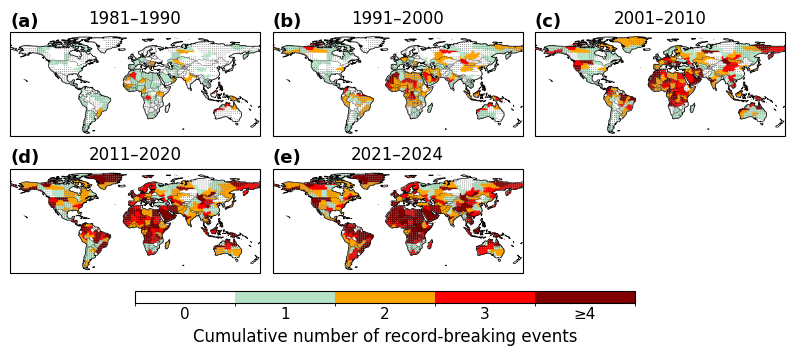

In [14]:
# ==========================================
# Record count（累计版本 + 3+2 layout）
# ==========================================
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.colors import BoundaryNorm, ListedColormap
from matplotlib.gridspec import GridSpec

# ==========================================
# Load data
# ==========================================
ds = xr.open_dataset(
    "Berkeley_hottest_month_by_region_revised_by_ERA5.nc"
).sel(year=slice(1940, 2024))

region_mask_ds = xr.open_dataset(
    "/home/users/kastanie/Global_regional_analysis/atmos-WRAF01-v4-1/region_mask_1deg.nc"
)

fidelity_ds = xr.open_dataset(
    "grid_comparison_fidelity_trend_corrected.nc"
)

region_id_map = region_mask_ds["region_id"]
lat = region_mask_ds["latitude"].values
lon = region_mask_ds["longitude"].values
extent = [lon.min(), lon.max(), lat.min(), lat.max()]

# ==========================================
# Low fidelity mask
# ==========================================
fidelity_mask = (fidelity_ds["fidelity_score"] == 3).values
land_mask = ~np.isnan(region_id_map)
fill_grey_mask = land_mask & (~fidelity_mask)

lon2d, lat2d = np.meshgrid(lon, lat)

sparse_mask = np.zeros_like(fill_grey_mask)
sparse_mask[::3, ::3] = True
low_fidelity_sparse = fill_grey_mask & sparse_mask

# ==========================================
# Periods
# ==========================================
periods = {
    "1981–1990": (1981, 1990),
    "1991–2000": (1991, 2000),
    "2001–2010": (2001, 2010),
    "2011–2020": (2011, 2020),
    "2021–2024": (2021, 2024),
}
period_names = list(periods.keys())

# ==========================================
# Record count calculation
# ==========================================
t2m = ds["t2m_hottest"]

t2m_base = t2m.sel(year=slice(1940, 1980))
record_tracker = t2m_base.max(dim="year")

record_count_maps = []

for pname in period_names:

    start, end = periods[pname]
    t2m_period = t2m.sel(year=slice(start, end))

    count = xr.zeros_like(record_tracker)

    for year in t2m_period.year.values:

        current = t2m.sel(year=year)
        is_record = current > record_tracker

        count = count + is_record.astype(int)

        record_tracker = xr.where(
            is_record,
            current,
            record_tracker
        )

    count_map = np.full(region_id_map.shape, np.nan)

    for rid in count.region_id.values:
        count_map[region_id_map.values == rid] = count.sel(region_id=rid).values

    record_count_maps.append(count_map)

# ==========================================
# cumulative
# ==========================================
record_count_maps = np.array(record_count_maps)

cumulative_maps = []
running_sum = np.zeros_like(record_count_maps[0])

for i in range(len(record_count_maps)):
    current = record_count_maps[i]

    current_filled = np.nan_to_num(current, nan=0.0)
    running_sum = running_sum + current_filled

    mask_all_nan = np.all(np.isnan(record_count_maps[:i+1]), axis=0)
    running_sum_masked = running_sum.copy()
    running_sum_masked[mask_all_nan] = np.nan

    cumulative_maps.append(running_sum_masked)

# ==========================================
# Colormap
# ==========================================
bounds = [0, 1, 2, 3, 4, 5]

colors = [
    "#FFFFFF",
    "#B7E4C7",
    "#FFA500",
    "#FF0000",
    "#800000"
]

cmap = ListedColormap(colors)
norm = BoundaryNorm(bounds, cmap.N)

# ==========================================
# Plot（3+2 layout）
# ==========================================
fig = plt.figure(figsize=(10, 3))
gs = GridSpec(2, 3, figure=fig)

axes = [
    fig.add_subplot(gs[0, 0], projection=ccrs.PlateCarree()),
    fig.add_subplot(gs[0, 1], projection=ccrs.PlateCarree()),
    fig.add_subplot(gs[0, 2], projection=ccrs.PlateCarree()),
    fig.add_subplot(gs[1, 0], projection=ccrs.PlateCarree()),
    fig.add_subplot(gs[1, 1], projection=ccrs.PlateCarree()),
]

labels = ["(a)", "(b)", "(c)", "(d)", "(e)"]

for i, ax in enumerate(axes):

    ax.set_extent([-180, 180, -60, 90])
    ax.coastlines(linewidth=0.5)
    ax.add_feature(cfeature.BORDERS, linewidth=0.2)

    ax.set_title(period_names[i], fontsize=12)

    ax.imshow(
        cumulative_maps[i],
        origin="lower",
        extent=extent,
        transform=ccrs.PlateCarree(),
        cmap=cmap,
        norm=norm
    )

    ax.scatter(
        lon2d[low_fidelity_sparse],
        lat2d[low_fidelity_sparse],
        s=0.5,
        color="grey",
        edgecolors="none",
        transform=ccrs.PlateCarree(),
        zorder=5
    )

    ax.text(
        0.00, 1.05,
        labels[i],
        transform=ax.transAxes,
        fontsize=13,
        fontweight='bold'
    )

# ==========================================
# layout
# ==========================================
fig.subplots_adjust(hspace=0.02, wspace=0.05, top=0.92, bottom=0.02)

# ==========================================
# Colorbar（横跨中间）
# ==========================================
cax = fig.add_axes([0.25, -0.03, 0.5, 0.04])

cb = fig.colorbar(
    plt.cm.ScalarMappable(cmap=cmap, norm=norm),
    cax=cax,
    orientation="horizontal",
    ticks=[0.5, 1.5, 2.5, 3.5, 4.5]
)

cb.ax.set_xticklabels(["0", "1", "2", "3", "≥4"])
cb.ax.tick_params(labelsize=11, length=0)

cb.set_label(
    "Cumulative number of record-breaking events",
    fontsize=12
)

# ==========================================
# Save
# ==========================================
plt.savefig(
    "FigS_record_count_cumulative.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()